In [122]:
import geopandas as gpd
from pathlib import Path
from shapely.geometry import Point
from matplotlib import pyplot as plt
import pandas as pd
import yaml
import numpy as np
import seaborn as sns
from matplotlib.ticker import MultipleLocator
from pointpats import PointPattern

In [123]:
plt.style.use("ggplot")
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'grid.color': '#e5e5e5',
    'grid.linestyle': '-',
    'grid.linewidth': 0.8,
})
pd.options.display.float_format = '{:.2f}'.format
root = Path.cwd().parent
assets_folder = Path(root, "assets")
data_folder = Path(root, "data")
with Path(root, "conf", "config").with_suffix(".yaml").open("r") as configfile:
    conf = yaml.safe_load(configfile)


In [124]:
canada = gpd.read_parquet(Path(assets_folder, "canada.pq"))

In [125]:
fires = gpd.read_file(Path(root, "data", "CANADA_WILDFIRES.csv"))
fires = gpd.GeoDataFrame(fires,
                         geometry = [Point(xy) for xy in zip(fires["LONGITUDE"], fires["LATITUDE"])],
                         crs = conf["crs"])
fires = fires[fires.within(canada.union_all())]
fires["SIZE_HA"] = pd.to_numeric(fires["SIZE_HA"])
fires = fires[fires["ECOZ_NAME"] != " "]
fires["REP_DATE"] = pd.to_datetime(fires["REP_DATE"], errors="coerce")
fires = fires.dropna(subset=["REP_DATE"])
fires["year"] = fires["REP_DATE"].dt.year
fires["REP_DATE"].dt.month
fires["SIZE_HA_LOG"] = np.log1p(fires["SIZE_HA"])
fires.isna().sum()


FID            0
SRC_AGENCY     0
LATITUDE       0
LONGITUDE      0
REP_DATE       0
SIZE_HA        0
CAUSE          0
PROTZONE       0
ECOZ_NAME      0
geometry       0
year           0
SIZE_HA_LOG    0
dtype: int64

In [126]:
fires.groupby("ECOZ_NAME")["ECOZ_NAME"].value_counts()

ECOZ_NAME
Atlantic Maritime      22238
Boreal Cordillera       9026
Boreal PLain           77310
Boreal Shield East     67451
Boreal Shield West     56683
Hudson Plain            2049
MixedWood Plain         4446
Montane Cordillera    120733
Northern Arctic            4
Pacific Maritime       19616
Prairie                 1399
Southern Arctic          265
Taiga Cordillera        1077
Taiga Plain            16855
Taiga Shield East       1467
Taiga Shield West       7949
Name: count, dtype: int64

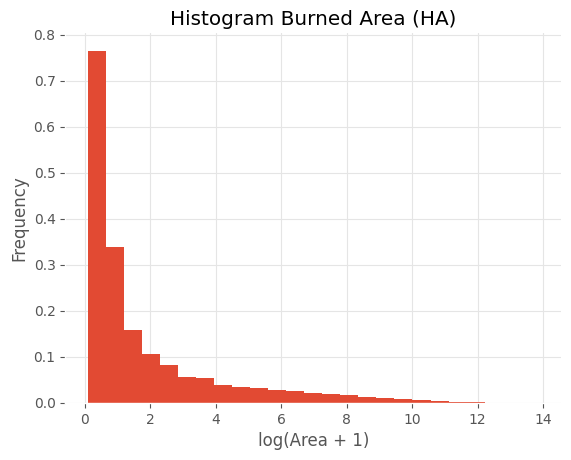

In [138]:
fires["SIZE_HA_LOG"].plot(kind = "hist",bins = 25,  density = True)
plt.title("Histogram Burned Area (HA)")
plt.xlabel("log(Area + 1)")
plt.show()

In [127]:
fires = fires[~fires["ECOZ_NAME"].str.contains("Arctic")]
fires = fires[fires["SIZE_HA"] > fires["SIZE_HA"].quantile(0.5)]

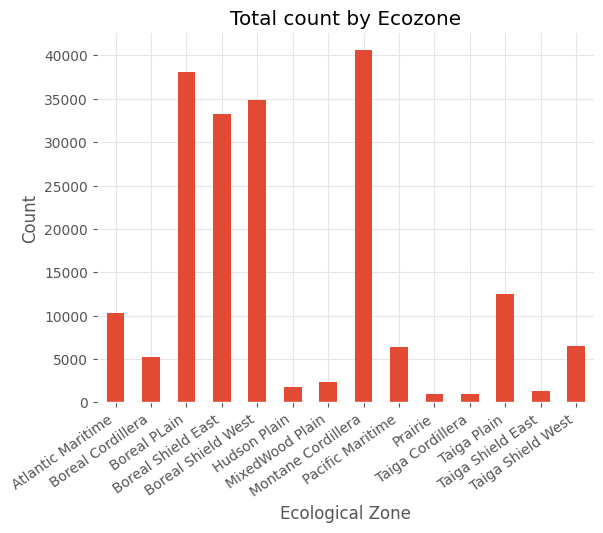

In [139]:
fires.groupby("ECOZ_NAME")["ECOZ_NAME"].value_counts().plot(kind = "bar")
plt.xticks(rotation = 35, ha = "right")
plt.xlabel("Ecological Zone")
plt.ylabel("Count")
plt.title("Total count by Ecozone")
plt.show()

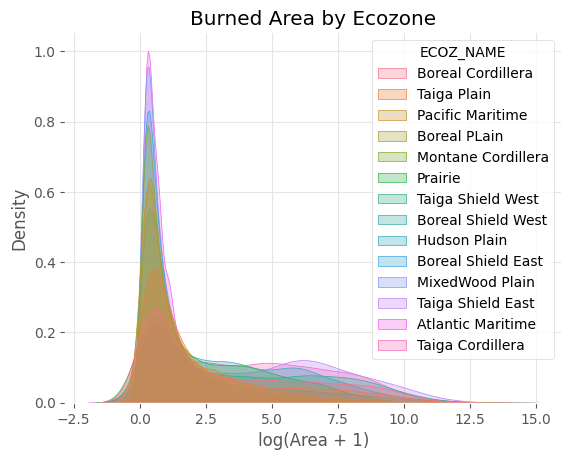

In [141]:
sns.kdeplot(data=fires, x="SIZE_HA_LOG", hue="ECOZ_NAME",
            fill=True, alpha=0.3, common_norm=False)
plt.xlabel("log(Area + 1)")
plt.title("Burned Area by Ecozone")
plt.show()

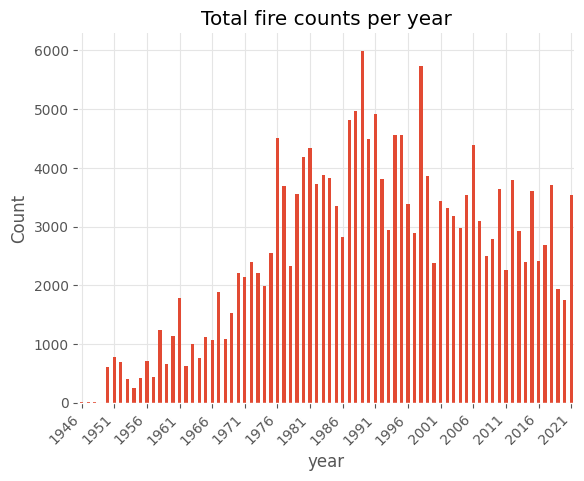

In [130]:
ax = fires["year"].value_counts().sort_index().plot(kind = "bar")
ax.xaxis.set_major_locator(MultipleLocator(5))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.title("Total fire counts per year")
plt.ylabel("Count")
plt.show()

In [131]:
fires_pp = PointPattern(np.array([[p.x, p.y] for p in fires.geometry]))

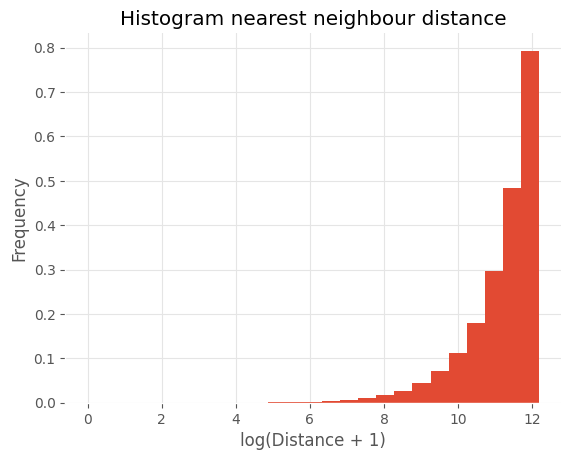

In [137]:
plt.hist(np.log1p(fires_pp.knn(k=2)[0][:, 1]), bins = 25, density=True)
plt.xlabel("log(Distance + 1)")
plt.ylabel("Frequency")
plt.title("Histogram nearest neighbour distance")
plt.show()